# Statistical analysis
**Author:** [Joel Perez Guerrero]  
**Tools:** Python, pandas, numpy, seaborn, matplotlib, scipy.
-In this notebook we perform statistical test to get a deeper understanding about dataset.
1. Normality tests , hypothesis tests grouped by brand.
- Shapiro-Wilk test.
- D`Agostino K^2 test.


In [6]:
import pandas as pd
from scipy.stats import shapiro, normaltest

df_03 = pd.read_parquet('../data/clean_data.parquet')

# We define an empty list
resultados_normalidad = []

# Group by brand
for marca, grupo in df_03.groupby('marcas_cl'):
    # Safety step
    if len(grupo) < 3:
        continue
    # 1. Shapiro test    
    data = grupo['venta_unitaria']
    _, p_val_sw = shapiro(data)
    
    # 2. Agostino test 
    p_val_dag = None
    if len(data) >= 8:
        _, p_val_dag = normaltest(data)
    
    resultados_normalidad.append({
        'Marca': marca,
        'Muestras': len(data),
        'P-Value (Shapiro)': round(p_val_sw, 4),
        'P-Value (K2)': round(p_val_dag, 4) if p_val_dag is not None else "N/A",
        'Is it Normal? alpha=0.05)': "Yes" if p_val_sw > 0.05 else "No"
    })

# Report
df_reporte = pd.DataFrame(resultados_normalidad)
print(df_reporte)

        Marca  Muestras  P-Value (Shapiro)  P-Value (K2)  \
0  Alfa Romeo     10782                0.0           0.0   
1       Dodge     42702                0.0           0.0   
2        Fiat    107291                0.0           0.0   
3        Jeep    161135                0.0           0.0   
4     Peugeot     80248                0.0           0.0   
5         RAM    134163                0.0           0.0   

  Is it Normal? alpha=0.05)  
0                        No  
1                        No  
2                        No  
3                        No  
4                        No  
5                        No  


/home/joe/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


2. Histograms by brand.

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values

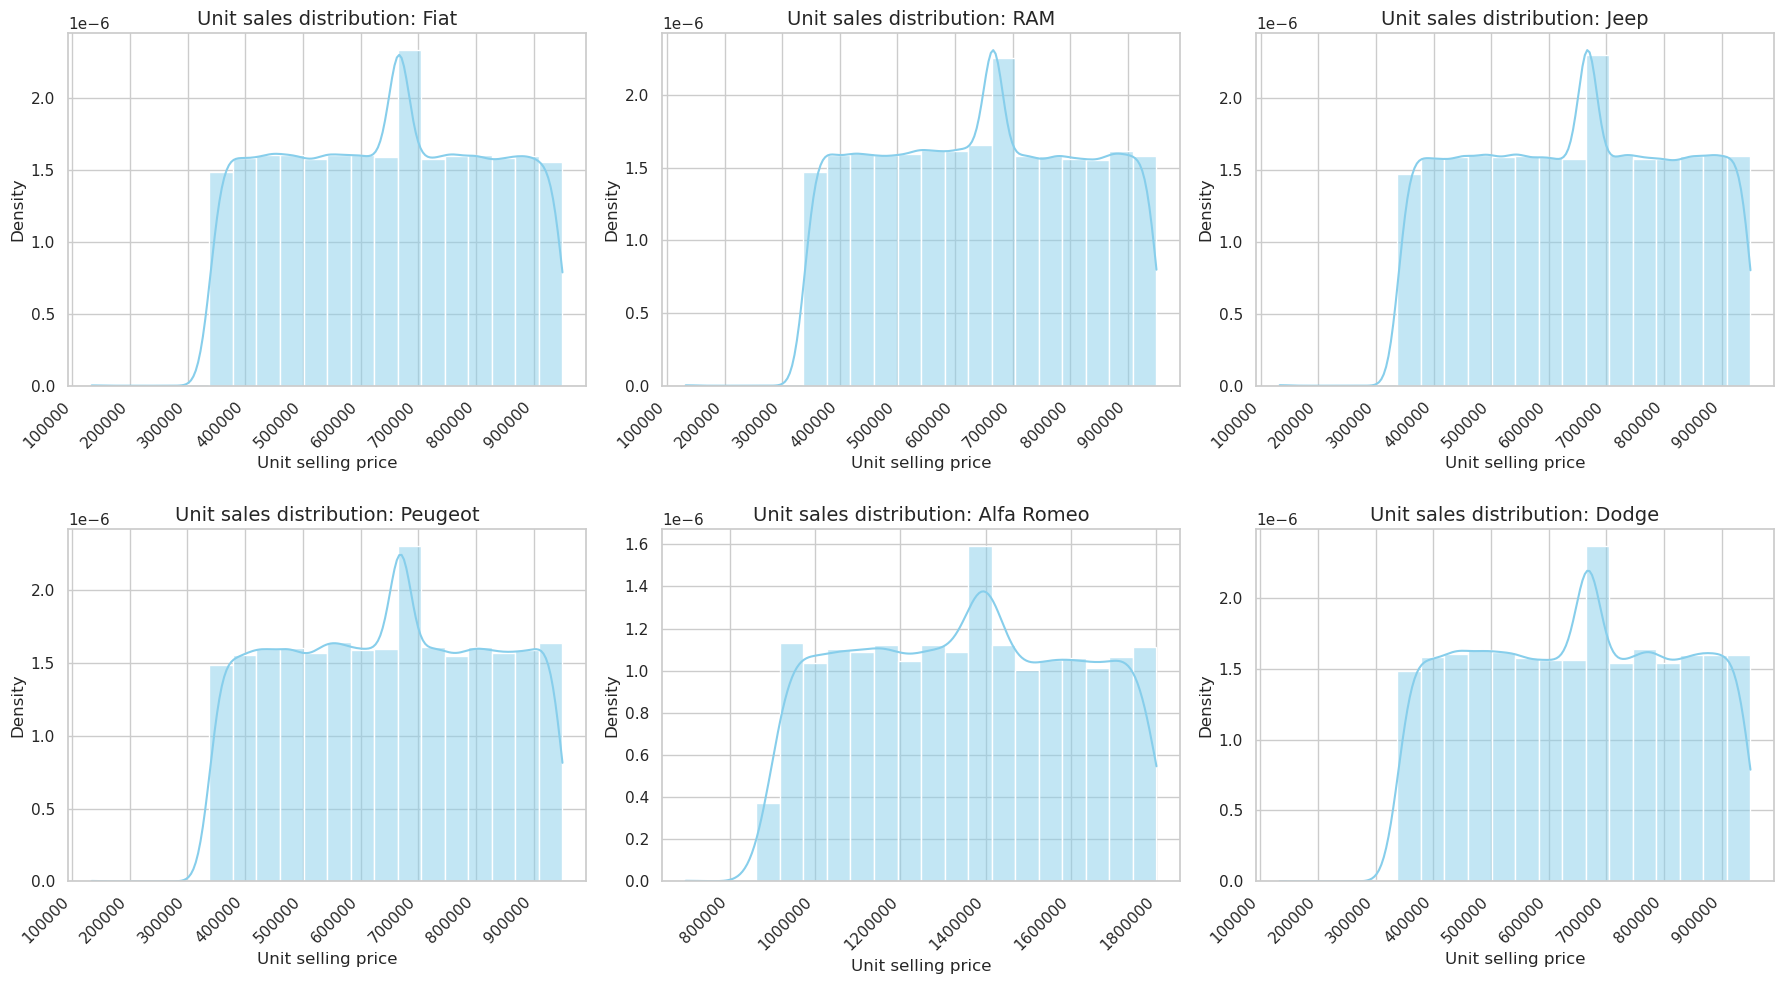

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

marcas = df_03['marcas_cl'].unique()
n_marcas = len(marcas)

ncols = 3
nrows = int(np.ceil(n_marcas / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() 

# Iterate by brand
for i, marca in enumerate(marcas):
    if i < len(axes):
        datos_marca = df_03[df_03['marcas_cl'] == marca]['venta_unitaria']
        
        sns.histplot(datos_marca, kde=True, ax=axes[i], color='skyblue', stat="density", bins=20)
        
        axes[i].set_title(f'Unit sales distribution: {marca}', fontsize=14)
        axes[i].set_xlabel('Unit selling price', fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        
        axes[i].ticklabel_format(style='plain', axis='x')
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('../graphs/distribution_unit_sales_by_brand.png', dpi=300)
plt.show()

3. Normality tests , hypothesis tests. grouped by brand and then by model
- Shapiro-Wilk

In [9]:
import pandas as pd
from scipy.stats import shapiro

resultados_modelos = []

# Group by brand and model
for (marca, modelo), grupo in df_03.groupby(['marcas_cl', 'modelo']):
    
    if len(grupo) >= 3:
        data = grupo['venta_unitaria']
        stat, p_val = shapiro(data)
        
        resultados_modelos.append({
            'Marca': marca,
            'Modelo': modelo,
            'Muestras': len(data),
            'P-Value': round(p_val, 4),
            'Is it normal?': "Yes" if p_val > 0.05 else "No"
        })

df_modelos = pd.DataFrame(resultados_modelos)
print(df_modelos.sort_values(by='Is it normal?', ascending=False))

         Marca          Modelo  Muestras  P-Value Is it normal?
0   Alfa Romeo          Giulia      3549      0.0            No
12        Jeep  Grand Cherokee     58786      0.0            No
21         RAM             700     19069      0.0            No
20         RAM            2500     19158      0.0            No
19         RAM            1500     76818      0.0            No
18     Peugeot         Manager     11297      0.0            No
17     Peugeot            5008     11654      0.0            No
16     Peugeot            3008     11428      0.0            No
15     Peugeot            2008     45869      0.0            No
14        Jeep        Wrangler     58791      0.0            No
13        Jeep        Renegade     14678      0.0            No
11        Jeep       Gladiator     14506      0.0            No
1   Alfa Romeo         Stelvio      3629      0.0            No
10        Jeep         Compass     14374      0.0            No
9         Fiat           Pulse     15576

/home/joe/anaconda3/lib/python3.11/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


4. Histograms by model, example for Alfa Romeo.

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


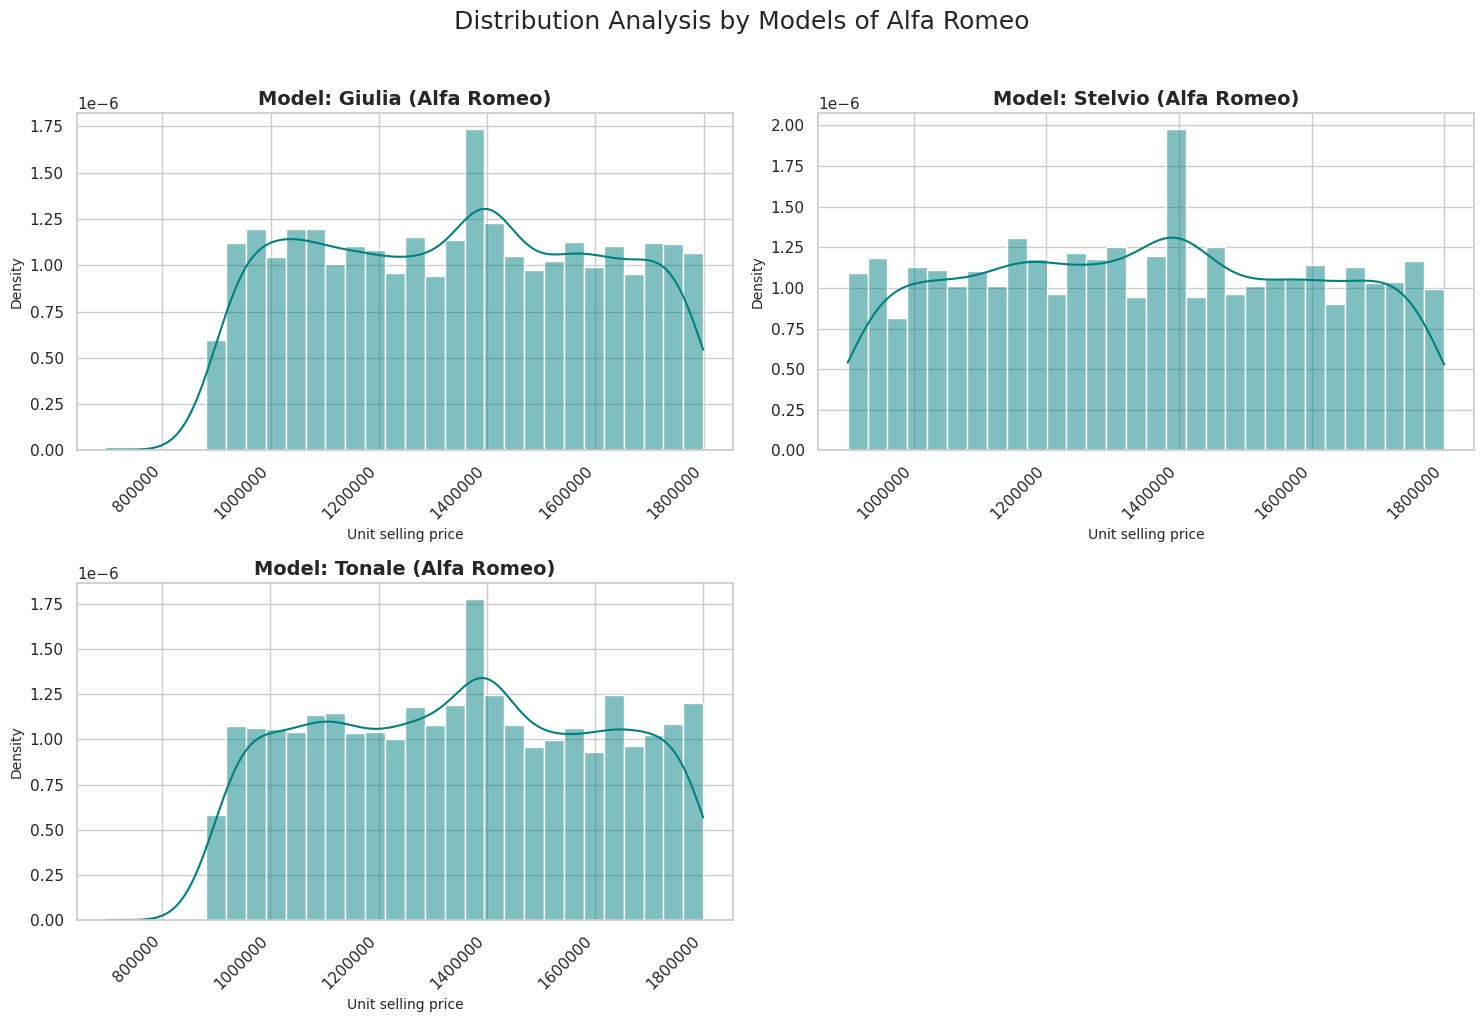

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

marca_objetivo = 'Alfa Romeo'
df_marca = df_03[df_03['marcas_cl'] == marca_objetivo]

modelos = df_marca['modelo'].unique()
n_modelos = len(modelos)

ncols = 2
nrows = int(np.ceil(n_modelos / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

#Iterate by model
for i, modelo in enumerate(modelos):
    if i < len(axes):
        datos_modelo = df_marca[df_marca['modelo'] == modelo]['venta_unitaria']
    
        sns.histplot(datos_modelo, kde=True, ax=axes[i], color='teal', stat="density", bins=30)
        
        axes[i].set_title(f'Model: {modelo} ({marca_objetivo})', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Unit selling price', fontsize=10)
        axes[i].set_ylabel('Density', fontsize=10)
        
        axes[i].ticklabel_format(style='plain', axis='x')
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

# Clean of empty axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'Distribution Analysis by Models of {marca_objetivo}', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('../graphs/unit_sales_distribution_by_model.png', dpi=300)
plt.show()

5. Once dataframe has been analyzed we upload claened and updated file to database. Ready for data Lake and visualization tools.

In [12]:
#DATA BASE CONNECTION SEETINGS
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# 1. Load variables from .env
load_dotenv(dotenv_path='../.env')

def get_connection():
    try:
        # 2. Get credentials
        user = os.getenv('DB_USER')
        password = os.getenv('DB_PASS')
        host = os.getenv('DB_HOST')
        port = os.getenv('DB_PORT')
        db = os.getenv('DB_NAME')

        # 3. Create connection engine
        url_conexion = f'postgresql://{user}:{password}@{host}:{port}/{db}'
        engine = create_engine(url_conexion)
        
        print("✅ Successful connection to pgAdmin.")
        return engine
    except Exception as e:
        print(f"❌ Error connecting: {e}")
        return None

# Execute connection
engine = get_connection()
df_03.drop(columns=['outliers'], inplace=True)

✅ Successful connection to pgAdmin.


In [ ]:
df_03.to_sql('fact_ventas_lake', engine, if_exists='replace', index=False)